In [ ]:
!pip install split-folders

In [ ]:
!pip install tensorflow

#Google Drive Mount

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


#Import Libraries

In [ ]:
import tensorflow as tf
from tensorflow.keras import models, layers
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import pandas as pd
from sklearn.preprocessing import LabelBinarizer
from sklearn.metrics import precision_recall_fscore_support

# Parameters

In [ ]:
BATCH_SIZE = 32
IMAGE_SIZE = 255
CHANNEL = 3
EPOCHS = 20

# Data splitting

In [ ]:
import splitfolders
input_folder = '/content/drive/MyDrive/Dataset'
output_folder = '/content/dataset'

splitfolders.ratio(
    input_folder,
    output=output_folder,
    seed=1337,
    ratio=(0.8, 0.1, 0.1)
)

Copying files: 2152 files [00:22, 94.11 files/s] 


# Load datasets

In [ ]:
train_dir = "/content/dataset/train"
val_dir = "/content/dataset/val"
test_dir = "/content/dataset/test"

train_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    shuffle=True,
    batch_size=BATCH_SIZE,
    image_size=(IMAGE_SIZE, IMAGE_SIZE)
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    val_dir,
    shuffle=True,
    batch_size=BATCH_SIZE,
    image_size=(IMAGE_SIZE, IMAGE_SIZE)
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    test_dir,
    shuffle=True,
    batch_size=BATCH_SIZE,
    image_size=(IMAGE_SIZE, IMAGE_SIZE)
)

class_names = train_ds.class_names
n_classes = len(class_names)
print("Class names:", class_names)
print("Number of classes:", n_classes)

Found 1721 files belonging to 3 classes.
Found 215 files belonging to 3 classes.
Found 216 files belonging to 3 classes.
Class names: ['Potato_early_blight', 'Potato_healthy', 'Potato_late_blight']
Number of classes: 3


# Preprocessing and augmentation

In [ ]:
resize_and_rescale = tf.keras.Sequential([
    layers.Resizing(IMAGE_SIZE, IMAGE_SIZE),
    layers.Rescaling(1./255),
])

data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal_and_vertical"),
    layers.RandomRotation(0.2),
])

def preprocess_dataset(dataset, augment=False):
    dataset = dataset.map(lambda x, y: (resize_and_rescale(x), y))
    if augment:
        dataset = dataset.map(lambda x, y: (data_augmentation(x, training=True), y))
    return dataset.prefetch(buffer_size=tf.data.AUTOTUNE)

train_ds = preprocess_dataset(train_ds, augment=True)
val_ds = preprocess_dataset(val_ds)
test_ds = preprocess_dataset(test_ds)

# Model architecture

In [ ]:
input_shape = (IMAGE_SIZE, IMAGE_SIZE, CHANNEL)

model = models.Sequential([
    layers.Conv2D(32, kernel_size=(3,3), activation='relu', input_shape=input_shape),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, kernel_size=(3,3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, kernel_size=(3,3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(n_classes, activation='softmax'),
])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_5 (Conv2D)               │ (None, 253, 253, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 126, 126, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 124, 124, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 62, 62, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 60, 60, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 12, 12, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 4608)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 256)            │     1,179,904 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,490,947 (5.69 MB)

 Trainable params: 1,490,947 (5.69 MB)

 Non-trainable params: 0 (0.00 B)

# Compile and train

In [ ]:
model.compile(
    optimizer='adam',
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False),
    metrics=['accuracy']
)

history = model.fit(
    train_ds,
    batch_size=BATCH_SIZE,
    validation_data=val_ds,
    verbose=1,              #progress bar dekhate 1, na dekhate 0
    epochs=EPOCHS,
)

Epoch 1/20
54/54 ━━━━━━━━━━━━━━━━━━━━ 31s 462ms/step - accuracy: 0.4709 - loss: 0.9594 - val_accuracy: 0.4651 - val_loss: 0.8639
Epoch 2/20
54/54 ━━━━━━━━━━━━━━━━━━━━ 23s 415ms/step - accuracy: 0.5198 - loss: 0.8600 - val_accuracy: 0.7209 - val_loss: 0.7645
Epoch 3/20
54/54 ━━━━━━━━━━━━━━━━━━━━ 22s 399ms/step - accuracy: 0.7385 - loss: 0.7016 - val_accuracy: 0.8326 - val_loss: 0.4903
Epoch 4/20
54/54 ━━━━━━━━━━━━━━━━━━━━ 21s 376ms/step - accuracy: 0.8361 - loss: 0.4355 - val_accuracy: 0.7721 - val_loss: 0.4856
Epoch 5/20
54/54 ━━━━━━━━━━━━━━━━━━━━ 22s 397ms/step - accuracy: 0.8475 - loss: 0.3893 - val_accuracy: 0.8093 - val_loss: 0.4943
Epoch 6/20
54/54 ━━━━━━━━━━━━━━━━━━━━ 21s 376ms/step - accuracy: 0.8781 - loss: 0.3215 - val_accuracy: 0.8791 - val_loss: 0.3068
Epoch 7/20
54/54 ━━━━━━━━━━━━━━━━━━━━ 22s 394ms/step - accuracy: 0.8574 - loss: 0.3575 - val_accuracy: 0.8791 - val_loss: 0.3755
Epoch 8/20
54/54 ━━━━━━━━━━━━━━━━━━━━ 21s 394ms/step - accuracy: 0.8993 - loss: 0.2532 - val_accu

# Save model

In [ ]:
model.save('model.h5')

# ENHANCED VISUALIZATIONS AND METRICS

## 1. Training History Graphs

In [ ]:
plt.figure(figsize=(15, 5))

<Figure size 1500x500 with 0 Axes>

<Figure size 1500x500 with 0 Axes>

### Accuracy plot

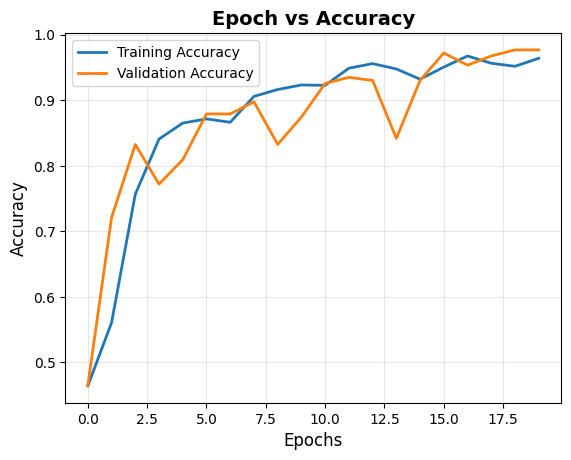

In [ ]:
plt.plot(history.history['accuracy'], label='Training Accuracy', linewidth=2)
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', linewidth=2)
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.title('Epoch vs Accuracy', fontsize=14, fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)

### Loss plot

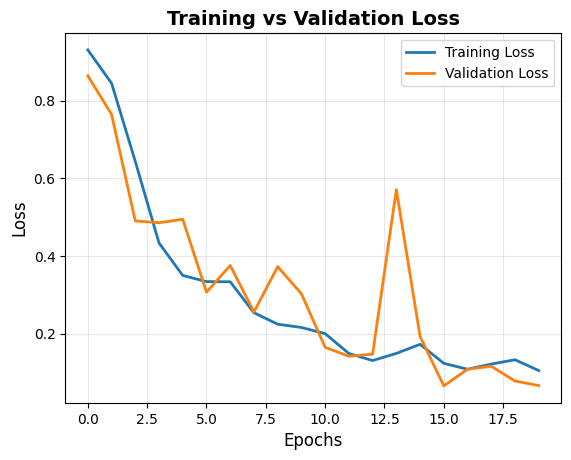

In [ ]:
plt.plot(history.history['loss'], label='Training Loss', linewidth=2)
plt.plot(history.history['val_loss'], label='Validation Loss', linewidth=2)
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.title('Training vs Validation Loss', fontsize=14, fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)

## 2. Model Evaluation and Metrics

### Get predictions

In [ ]:
y_true = []
y_pred_proba = []

for images, labels in test_ds:
    predictions = model.predict(images, verbose=0)
    y_true.extend(labels.numpy())
    y_pred_proba.extend(predictions)

y_true = np.array(y_true)
y_pred_proba = np.array(y_pred_proba)
y_pred = np.argmax(y_pred_proba, axis=1)

### Calculate metrics

In [ ]:
accuracy = accuracy_score(y_true, y_pred)
precision, recall, f1, support = precision_recall_fscore_support(y_true, y_pred, average=None)
macro_precision, macro_recall, macro_f1, _ = precision_recall_fscore_support(y_true, y_pred, average='macro')
weighted_precision, weighted_recall, weighted_f1, _ = precision_recall_fscore_support(y_true, y_pred, average='weighted')

### Print detailed classification report

In [ ]:
print("\n DETAILED CLASSIFICATION REPORT:")
print("="*40)
print(classification_report(y_true, y_pred, target_names=class_names, digits=4))


 DETAILED CLASSIFICATION REPORT:
                     precision    recall  f1-score   support

Potato_early_blight     0.9901    1.0000    0.9950       100
     Potato_healthy     0.8421    1.0000    0.9143        16
 Potato_late_blight     1.0000    0.9600    0.9796       100

           accuracy                         0.9815       216
          macro avg     0.9441    0.9867    0.9630       216
       weighted avg     0.9837    0.9815    0.9819       216



### Print overall metrics

In [ ]:
print("\n OVERALL METRICS:")
print("="*30)
print(f"Accuracy: {accuracy:.4f}")
print(f"Macro Precision: {macro_precision:.4f}")
print(f"Macro Recall: {macro_recall:.4f}")
print(f"Macro F1-Score: {macro_f1:.4f}")
print(f"Weighted F1-Score: {weighted_f1:.4f}")


 OVERALL METRICS:
Accuracy: 0.9815
Macro Precision: 0.9441
Macro Recall: 0.9867
Macro F1-Score: 0.9630
Weighted F1-Score: 0.9819


<Figure size 1000x800 with 0 Axes>

## 3. Confusion Matrix

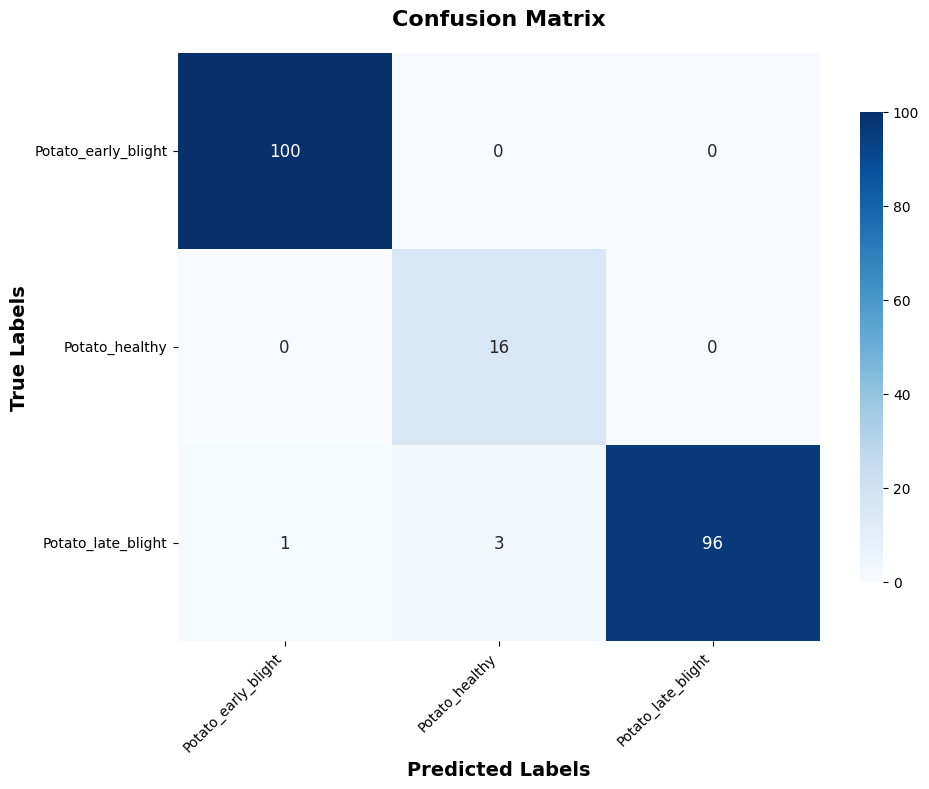

In [ ]:

plt.figure(figsize=(10, 8))
cm = confusion_matrix(y_true, y_pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names,
            cbar_kws={'shrink': 0.8}, annot_kws={'size': 12})

plt.xlabel('Predicted Labels', fontsize=14, fontweight='bold')
plt.ylabel('True Labels', fontsize=14, fontweight='bold')
plt.title('Confusion Matrix', fontsize=16, fontweight='bold', pad=20)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

## 4. Normalized Confusion Matrix

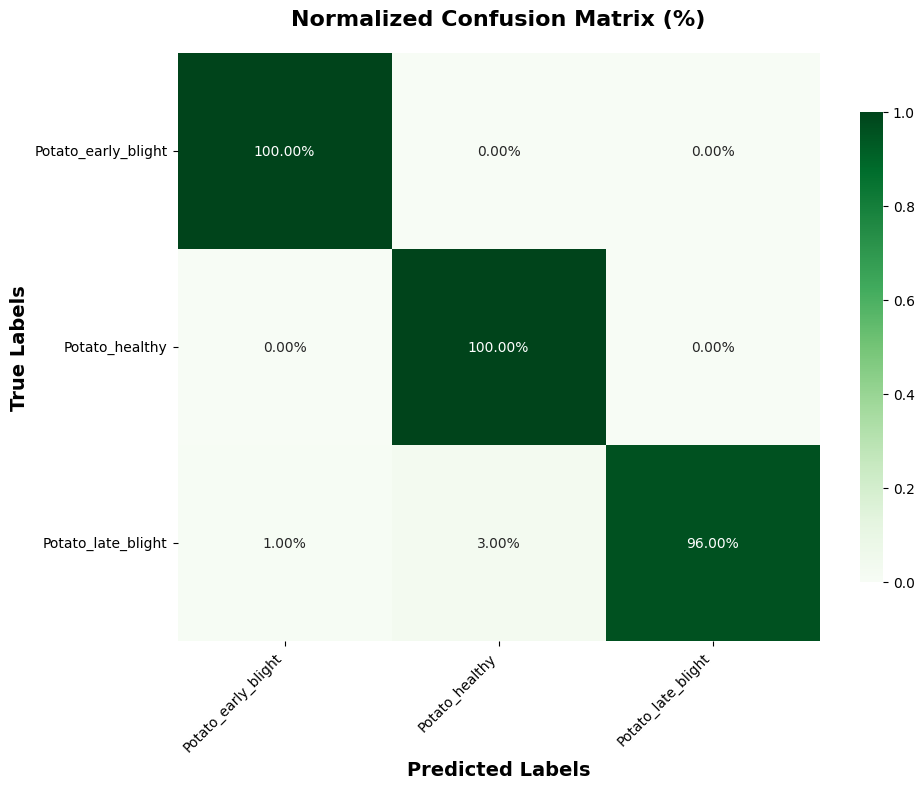

In [ ]:
plt.figure(figsize=(10, 8))

cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]


sns.heatmap(cm_normalized, annot=True, fmt='.2%', cmap='Greens',
            xticklabels=class_names, yticklabels=class_names,
            cbar_kws={'shrink': 0.8}, annot_kws={'size': 10})

plt.xlabel('Predicted Labels', fontsize=14, fontweight='bold')
plt.ylabel('True Labels', fontsize=14, fontweight='bold')
plt.title('Normalized Confusion Matrix (%)', fontsize=16, fontweight='bold', pad=20)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

## 5. Bar Chart of Accuracy Scores (Per-class metrics)

### Calculate per-class accuracy from confusion matrix



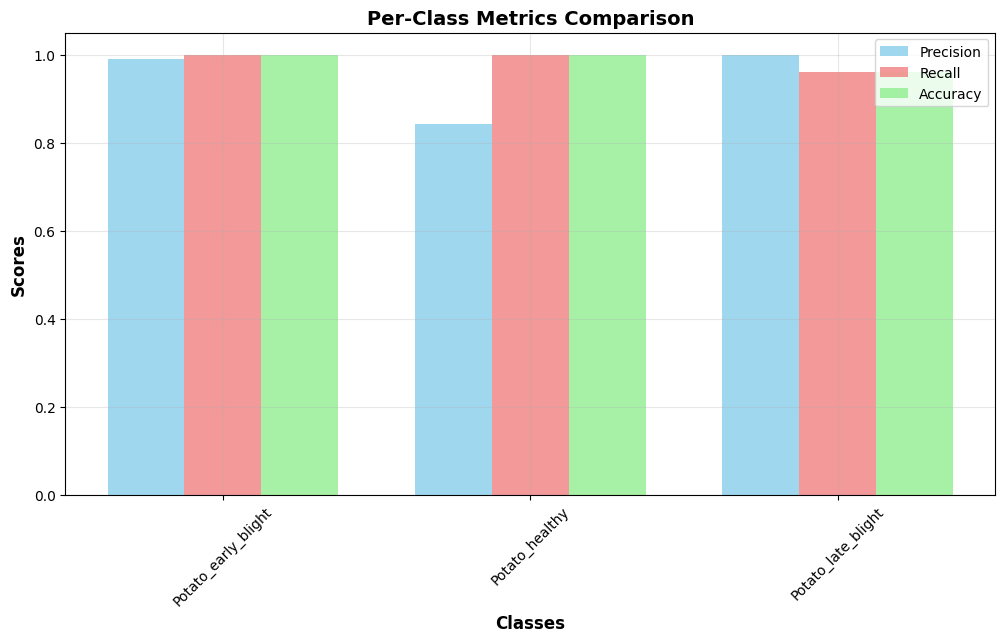

In [ ]:
plt.figure(figsize=(12, 6))

class_accuracy = cm.diagonal() / cm.sum(axis=1)


x_pos = np.arange(len(class_names))
width = 0.25

bars1 = plt.bar(x_pos - width, precision, width, label='Precision', alpha=0.8, color='skyblue')
bars2 = plt.bar(x_pos, recall, width, label='Recall', alpha=0.8, color='lightcoral')
bars3 = plt.bar(x_pos + width, class_accuracy, width, label='Accuracy', alpha=0.8, color='lightgreen')

plt.xlabel('Classes', fontsize=12, fontweight='bold')
plt.ylabel('Scores', fontsize=12, fontweight='bold')
plt.title('Per-Class Metrics Comparison', fontsize=14, fontweight='bold')
plt.xticks(x_pos, class_names, rotation=45)
plt.legend()
plt.grid(True, alpha=0.3)


### F1-Score bar chart

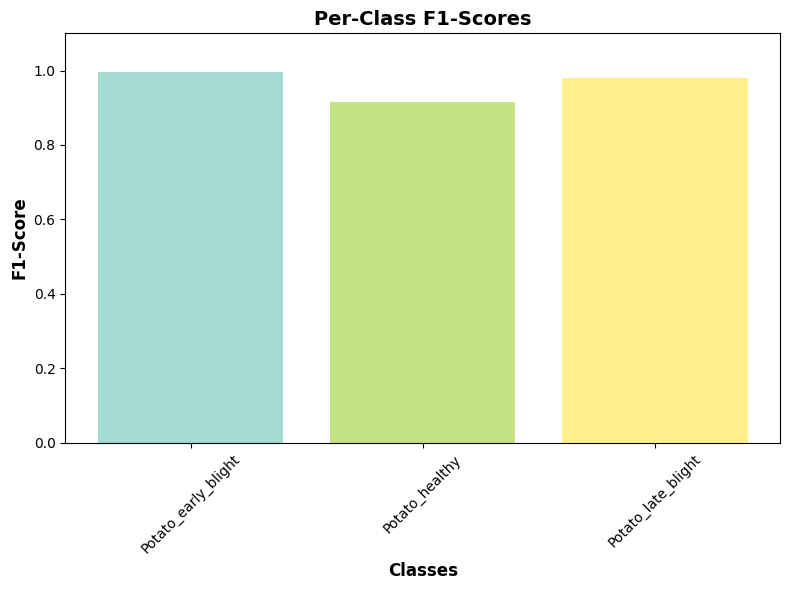

In [ ]:
plt.figure(figsize=(8, 6))
colors = plt.cm.Set3(np.linspace(0, 1, len(class_names)))
bars = plt.bar(class_names, f1, color=colors, alpha=0.8)

plt.xlabel('Classes', fontsize=12, fontweight='bold')
plt.ylabel('F1-Score', fontsize=12, fontweight='bold')
plt.title('Per-Class F1-Scores', fontsize=14, fontweight='bold')
plt.xticks(rotation=45)
plt.ylim(0, 1.1)

plt.tight_layout()
plt.show()

## 6. Overall Metrics Comparison

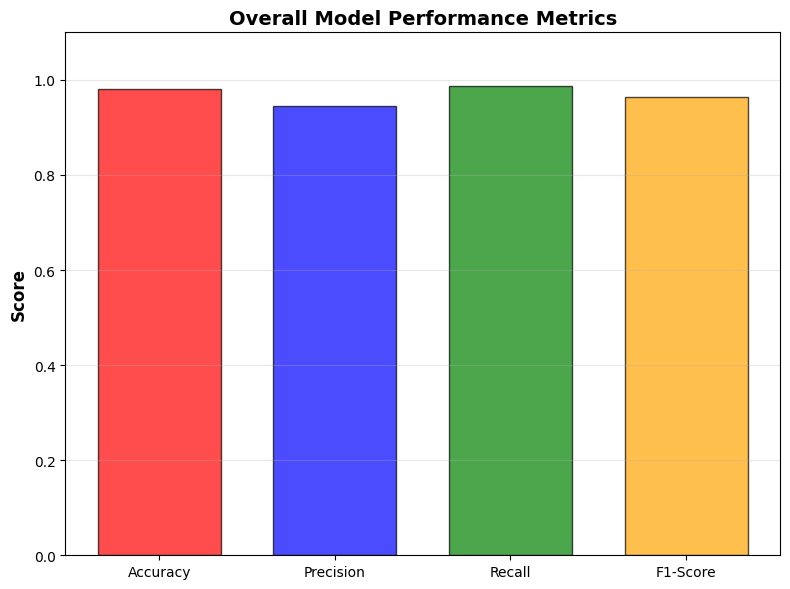

In [ ]:
plt.figure(figsize=(8, 6))
overall_metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
overall_values = [accuracy, macro_precision, macro_recall, macro_f1]

colors = ['red', 'blue', 'green', 'orange']
plt.bar(overall_metrics, overall_values, color=colors, alpha=0.7, edgecolor='black', width=0.7)

plt.ylabel('Score', fontsize=12, fontweight='bold')
plt.title('Overall Model Performance Metrics', fontsize=14, fontweight='bold')
plt.ylim(0, 1.1)

plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

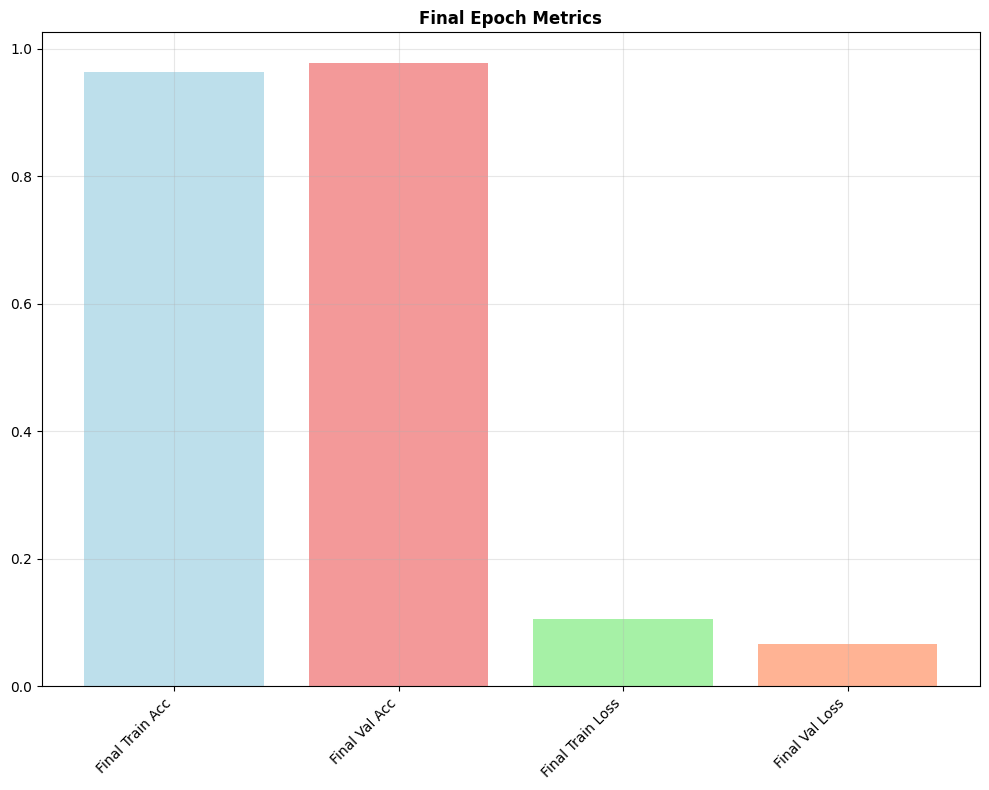

In [ ]:

plt.figure(figsize=(10, 8))

final_epoch_metrics = {
    'Final Train Acc': history.history['accuracy'][-1],
    'Final Val Acc': history.history['val_accuracy'][-1],
    'Final Train Loss': history.history['loss'][-1],
    'Final Val Loss': history.history['val_loss'][-1]
}

metrics_names = list(final_epoch_metrics.keys())
metrics_values = list(final_epoch_metrics.values())

colors = ['lightblue', 'lightcoral', 'lightgreen', 'lightsalmon']
plt.bar(metrics_names, metrics_values, color=colors, alpha=0.8)
plt.title('Final Epoch Metrics', fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
# 8. Print final summary
print("\n" + "="*60)
print("             TRAINING SUMMARY")
print("="*60)
print(f"Final Training Accuracy: {history.history['accuracy'][-1]:.4f}")
print(f"Final Validation Accuracy: {history.history['val_accuracy'][-1]:.4f}")
print(f"Final Training Loss: {history.history['loss'][-1]:.4f}")
print(f"Final Validation Loss: {history.history['val_loss'][-1]:.4f}")
print(f"Test Accuracy: {accuracy:.4f}")
print(f"Number of Epochs: {EPOCHS}")
print(f"Total Parameters: {model.count_params():,}")
print("="*60)


             TRAINING SUMMARY
Final Training Accuracy: 0.9640
Final Validation Accuracy: 0.9767
Final Training Loss: 0.1049
Final Validation Loss: 0.0663
Test Accuracy: 0.9815
Number of Epochs: 20
Total Parameters: 1,490,947


#Sample Image Prediction

first image to predict
actual label: Potato_early_blight
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step
predicted label: Potato_early_blight


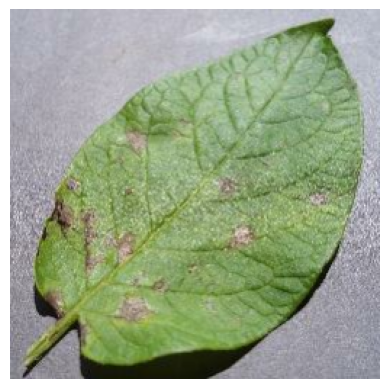

In [ ]:
import numpy as np
for images_batch, labels_batch in test_ds.take(1):

    first_image = (images_batch[0].numpy()*255).astype('uint8')
    first_label = labels_batch[0].numpy()

    print("first image to predict")
    plt.imshow(first_image)
    print("actual label:",class_names[first_label])

    batch_prediction = model.predict(images_batch)
    print("predicted label:",class_names[np.argmax(batch_prediction[0])])
    plt.axis("off")

#Batch Image Prediction

In [ ]:
def predict(model, img):
    img_array = tf.keras.preprocessing.image.img_to_array(img)
    img_array = tf.expand_dims(img_array, 0)
    img_array = resize_and_rescale(img_array)

    predictions = model.predict(img_array, verbose=0)

    predicted_class = class_names[np.argmax(predictions[0])]
    confidence = round(100 * (np.max(predictions[0])), 2)
    return predicted_class, confidence

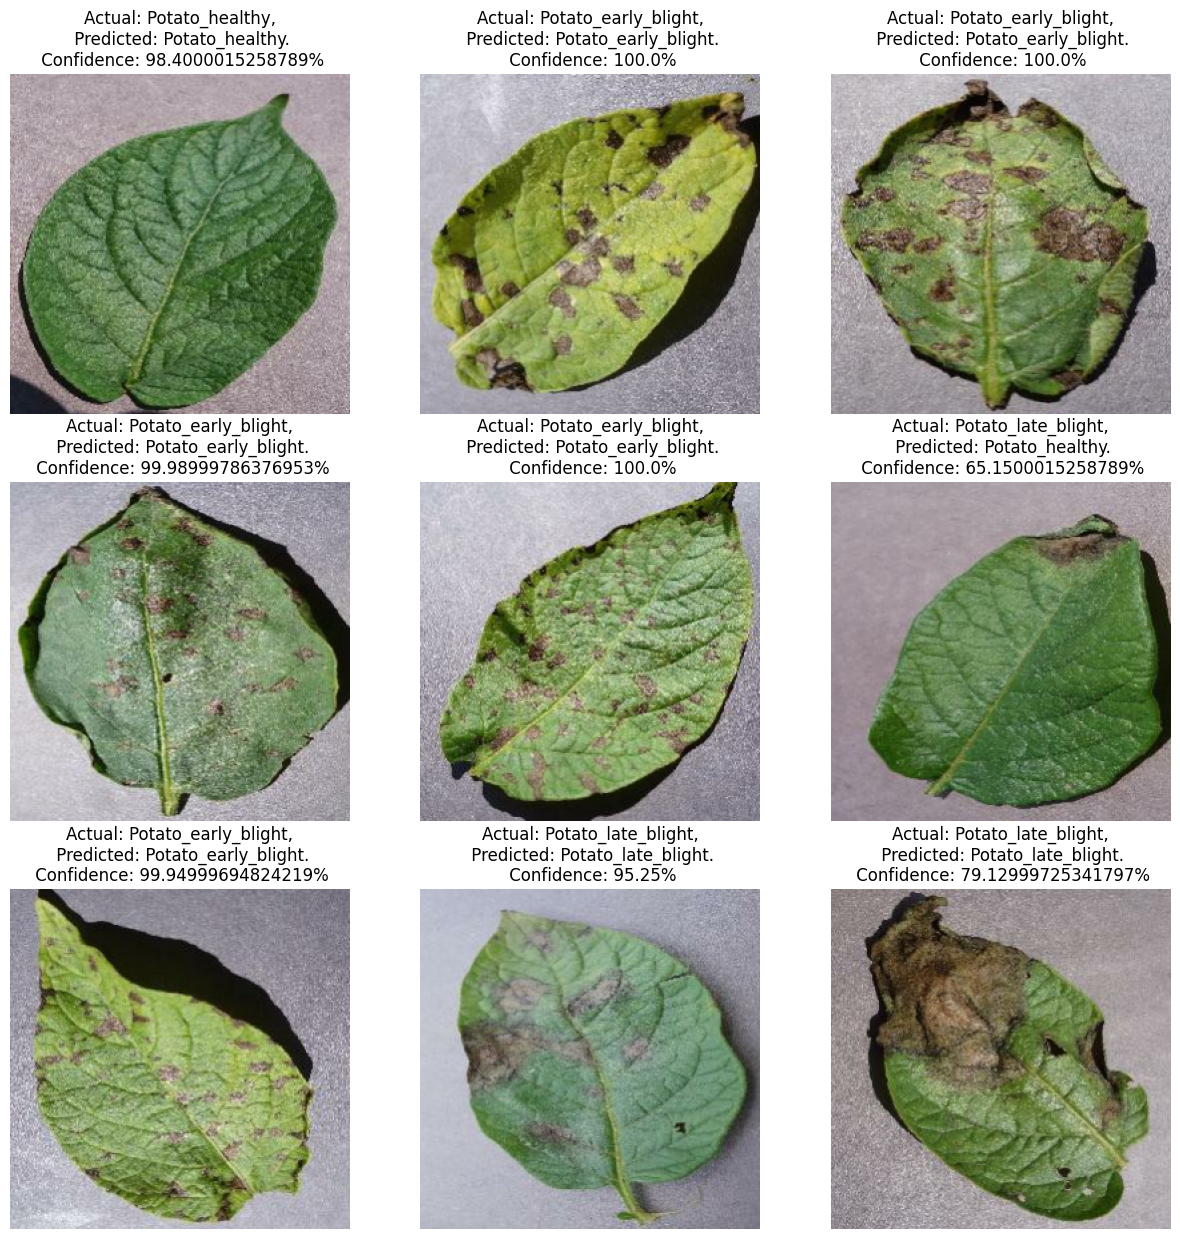

In [ ]:
plt.figure(figsize=(15, 15))
for images, labels in test_ds.take(1):
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow((images[i].numpy()*255).astype("uint8"))

        predicted_class, confidence = predict(model, (images[i].numpy()*255))
        actual_class = class_names[labels[i]]

        plt.title(f"Actual: {actual_class},\n Predicted: {predicted_class}.\n Confidence: {confidence}%")

        plt.axis("off")